## Computer Vision

### Building a CNN from scratch: Cat vs Dog

#### The pipeline you are building

* Image (any size, JPEG on disk)
* **↓ Transform / preprocessing**
* Tensor (3 x 128 x 128)
* **↓ Conv + ReLU + Pool (x3)**
* Feature maps (64 x 16 x 16)
* **↓ Flatten**
* Feature vector (16384 numbers)
* **↓ Linear classifier**
* One logit
* **↓ sigmoid**
* P(dog)

## 0. Setup

In [2]:
# Run once if needed, then comment it out again:
# %pip install torch torchvision matplotlib pillow

import random
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image

print("torch :", torch.__version__)
print("numpy :", np.__version__)

torch : 2.14.0+cpu
numpy : 2.5.3


## 0.1 Reproducibility and device

**Seeds.** A CNN starts with random filters, the data is shuffled in a random order, and augmentation flips images at random. Setting a seed ensures that whenever you rerun the notebook you get the same numbers — so any difference you see later was caused by the change you made, not random luck

**Device.** `cuda` if you have an NVIDIA GPU, otherwise `cpu`. Everything here is small enough to train on a CPU in a few minutes anyway. Whatever it prints, the rest of the notebook works


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [4]:
# Change this line if your images are somewhere else.
SOURCE_DIR = Path("data")

CAT_DIR = SOURCE_DIR / "Cat"
DOG_DIR = SOURCE_DIR / "Dog"

cat_files = sorted(CAT_DIR.glob("*.jpg"))
dog_files = sorted(DOG_DIR.glob("*.jpg"))

print("Source folder :", SOURCE_DIR.resolve())
print("Cat images   :", len(cat_files))
print("Dog images   :", len(dog_files))


Source folder : C:\Users\USER PC\OneDrive\Desktop\computer vision\project_4\data
Cat images   : 12499
Dog images   : 12499


## 0.3 Building a small train / val / test split

The full dataset is 25,000 images. We deliberately use only a small part of it; a couple of thousand images is enough to watch a CNN training run down to a few minutes on a laptop. 
 We are going to build this folder structure, which is exactly what torchvision expects:   



```text
dataset/
├── train/
│   ├── cats/    1000 images
│   └── dogs/    1000 images
├── val/
│   ├── cats/     200 images
│   └── dogs/     200 images
└── test/
    ├── cats/     200 images
    └── dogs/     200 images


Two small helper functions do the work:

* `good_images(...)` keeps only files that PIL can actually open. This dataset really does contain a few broken JPEGs, and it is much nicer than to have training crash halfway through.
* `copy_images(...)` copies a list of files into a folder.

Then we shuffle (with the seed, so everyone gets the same split), slice the list into three parts, and copy. The three splits never share images—the whole point of splitting, and Section 3 explains why.

In [5]:
def good_images(files, how_many):
    """Return the first `how_many` files that PIL can open without an error."""
    good = []
    for file in files:
        if len(good) == how_many:
            break
        try:
            Image.open(file).convert("RGB")   # if this works, the file is fine
            good.append(file)
        except Exception:
            print("Skipping unreadable file:", file.name)
    return good

def copy_images(files, folder):
    """Copy a list of files into `folder`, creating it if needed."""
    folder.mkdir(parents=True, exist_ok=True)
    for file in files:
        shutil.copy(file, folder / file.name)


In [6]:
DATA_ROOT = Path("dataset")

N_TRAIN = 1000  # images per class
N_VAL = 200
N_TEST = 200
N_TOTAL = N_TRAIN + N_VAL + N_TEST

if DATA_ROOT.exists():
    print(f"{DATA_ROOT}/ already exists — skipping. Delete the folder if you want to rebuild it.")
else:
    for class_name, files in [("cats", cat_files), ("dogs", dog_files)]:
        print("preparing", class_name)

        random.Random(SEED).shuffle(files)  # Same shuffle for everyone
        selected = good_images(files, N_TOTAL)

        train_part = selected[:N_TRAIN]
        val_part = selected[N_TRAIN:N_TRAIN + N_VAL]
        test_part = selected[N_TRAIN + N_VAL:]

        copy_images(train_part, DATA_ROOT / "train" / class_name)
        copy_images(val_part, DATA_ROOT / "val" / class_name)
        copy_images(test_part, DATA_ROOT / "test" / class_name)

print("Done.")


dataset/ already exists — skipping. Delete the folder if you want to rebuild it.
Done.


In [7]:
# What did we end up with?
for split in ["train", "val", "test"]:
    n_cats = len(list((DATA_ROOT / split / "cats").glob("*.jpg")))
    n_dogs = len(list((DATA_ROOT / split / "dogs").glob("*.jpg")))
    print(f"{split:6s} cats: {n_cats:5d}  dogs: {n_dogs:5d}  total: {n_cats + n_dogs:5d}")


train  cats:  1000  dogs:  1000  total:  2000
val    cats:   200  dogs:   200  total:   400
test   cats:   200  dogs:   200  total:   400


## 1. Problem Definition

The task, stated precisely:
Given one photograph, decide: cat or dog.

This is binary image classification. Two words, both worth unpacking:
* Classification — the output is a category, not a number and not a location. We are not asked where the animal is in the picture, only what it is.
* Binary — exactly two categories, and every image in one or the other. This is what will let us get away with a single output number later on.

Let us look at what we are actually dealing with. First, a small helper for drawing images side by side — we will use it throughout the notebook.


In [8]:
def show_images(images, titles, columns=4, size=3):
    """Draw a row (or grid) of images with titles above them."""
    rows = int(np.ceil(len(images) / columns))
    plt.figure(figsize=(size * columns, size * rows))

    for i in range(len(images)):
        plt.subplot(rows, columns, i + 1)
        plt.imshow(images[i], cmap="gray")   # cmap is ignored for colour images
        plt.title(titles[i], fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


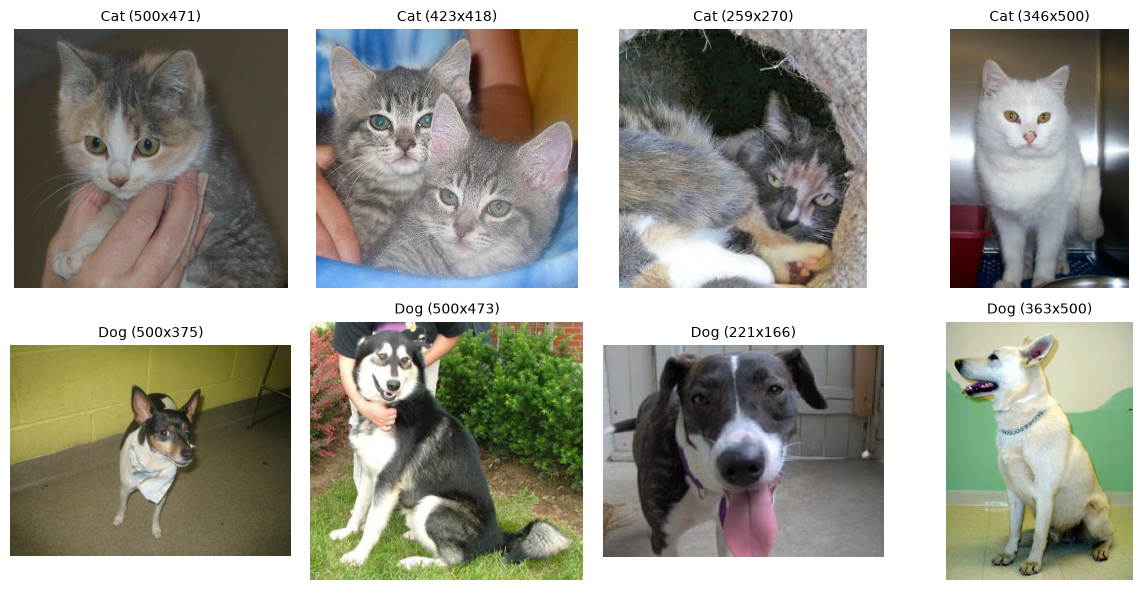

In [9]:
# The image files we will work with from now on
train_cat_paths = sorted((DATA_ROOT / "train" / "cats").glob("*.jpg"))
train_dog_paths = sorted((DATA_ROOT / "train" / "dogs").glob("*.jpg"))

# Four cats and four dogs, straight from disk, untouched
images = []
titles = []

for path in train_cat_paths[:4]:
    image = Image.open(path).convert("RGB")
    images.append(image)
    titles.append(f"Cat ({image.size[0]}x{image.size[1]})")

for path in train_dog_paths[:4]:
    image = Image.open(path).convert("RGB")
    images.append(image)
    titles.append(f"Dog ({image.size[0]}x{image.size[1]})")

show_images(images, titles)


## 2. Explore the Dataset

Before modelling anything, look at the data. Two questions:
1. How many images do we have, and where?
2. How similar are they to each other? (Spoiler: not very.)


In [10]:
def count_images(split, class_name):
    """Return how many jpg files are in dataset/<split>/<class_name>/."""
    return len(list((DATA_ROOT / split / class_name).glob("*.jpg")))

print("split  cats  dogs  total")
print("-" * 30)

for split in ["train", "val", "test"]:
    n_cats = count_images(split, "cats")
    n_dogs = count_images(split, "dogs")
    print(f"{split:6s} {n_cats:5d} {n_dogs:5d}  {n_cats + n_dogs:5d}")


split  cats  dogs  total
------------------------------
train   1000  1000   2000
val      200   200    400
test     200   200    400


## 2.1 A grid of real examples

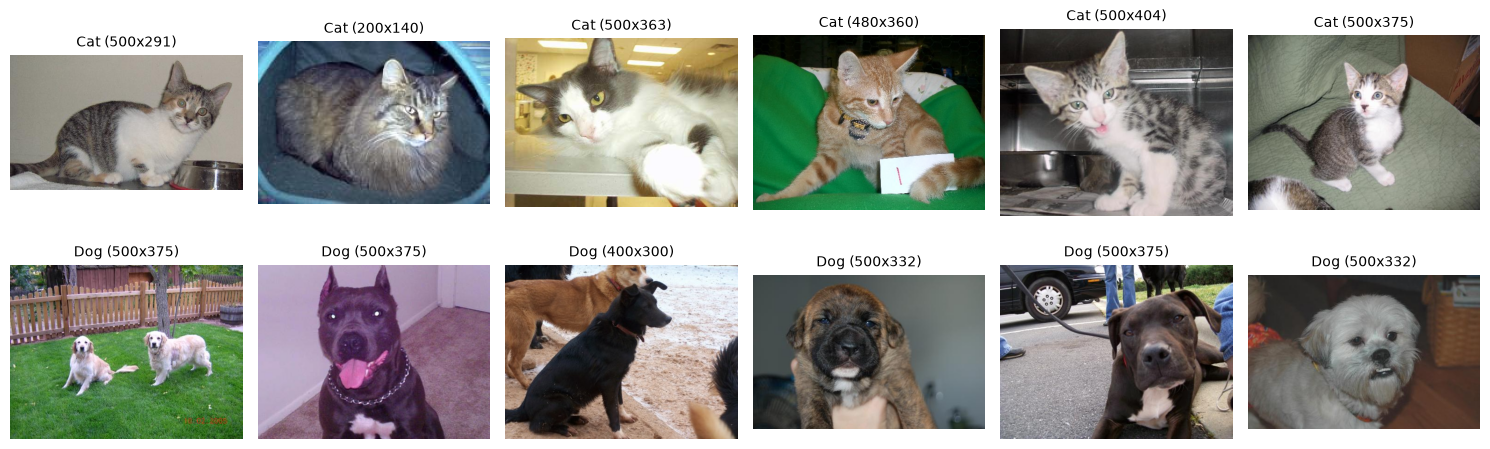

In [11]:

random.seed(SEED)

picked = random.sample(train_cat_paths, 6) + random.sample(train_dog_paths, 6)

images = []
titles = []

for i, path in enumerate(picked):
    image = Image.open(path).convert("RGB")
    images.append(image)
    titles.append(f"{'Cat' if i < 6 else 'Dog'} ({image.size[0]}x{image.size[1]})")

show_images(images, titles, columns=6, size=2.5)


## 2.2 How different are these images, really?

Let us measure the variation instead of just eyeballing it. We read the size of every training image and look at the range.

width  : smallest 50, largest 500, average 409
height : smallest 50, largest 500, average 363
ratio  : smallest 0.31, largest 3.19


c:\Users\USER PC\OneDrive\Desktop\computer vision\project_4\venv\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


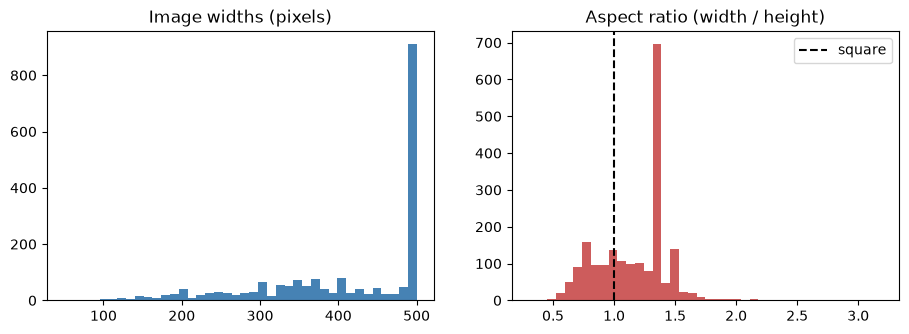

In [12]:
widths = []
heights = []

for path in train_cat_paths + train_dog_paths:
    image = Image.open(path)
    widths.append(image.size[0])
    heights.append(image.size[1])

widths = np.array(widths)
heights = np.array(heights)
ratios = widths / heights  # aspect ratio: wider than tall is > 1

print(f"width  : smallest {widths.min()}, largest {widths.max()}, average {widths.mean():.0f}")
print(f"height : smallest {heights.min()}, largest {heights.max()}, average {heights.mean():.0f}")
print(f"ratio  : smallest {ratios.min():.2f}, largest {ratios.max():.2f}")

plt.figure(figsize=(11, 3.5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=40, color="steelblue")
plt.title("Image widths (pixels)")

plt.subplot(1, 2, 2)
plt.hist(ratios, bins=40, color="indianred")
plt.axvline(1.0, color="black", linestyle="--", label="square")
plt.title("Aspect ratio (width / height)")
plt.legend()


## What that is telling you



Almost every image has a different size, and the shapes range from tall portraits to wide landscapes. On top of that, there are many variations including:

* **Different backgrounds** — sofa, grass, carpets, arms holding the animal.


* **Different poses** — sitting, lying, jumping, seen from behind.


* **Different scales** — a face filling the frame vs. a small animal in a big room.


* **Different lighting** — flash, daylight, shadows.


* **Clutter** — a hand, a blanket, a second animal in the image.



This matters for two separate reasons:

1. **Practically:** we cannot stack images of different sizes into one batch, so something has to give. That is Section 5.


2. **Conceptually:** the network has to find features that survive all this variation. A rule like "the cat is in the middle of the picture" would fail on the other photo.


## 3. Class Distribution

Now check the balance between the two classes. This is a quick check that people skip, and it changes how you are allowed to read every accuracy number afterwards.

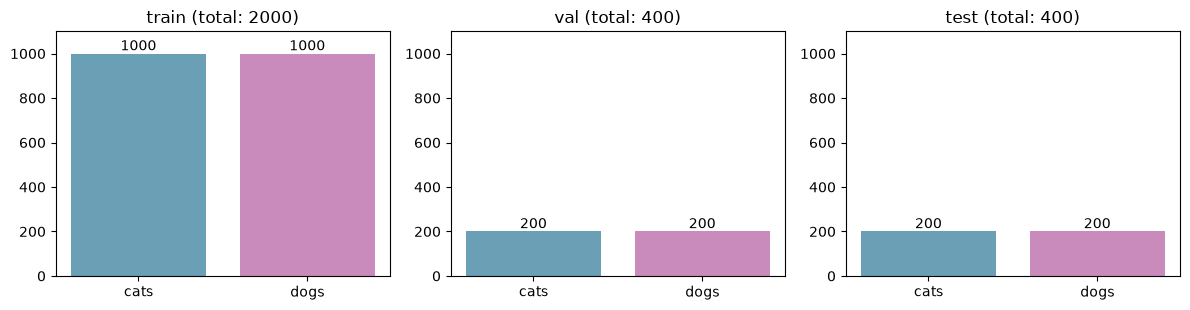

In [13]:
plt.figure(figsize=(12, 3.2))

for position, split in enumerate(["train", "val", "test"]):
    n_cats = count_images(split, "cats")
    n_dogs = count_images(split, "dogs")

    plt.subplot(1, 3, position + 1)
    bars = plt.bar(["cats", "dogs"], [n_cats, n_dogs], color=["#6a9fb5", "#c98bbb"])
    plt.bar_label(bars)
    plt.title(f"{split} (total: {n_cats + n_dogs})")
    plt.ylim(0, 1100)

plt.tight_layout()
plt.show()


Our dataset is balanced — 50 / 50 in every split

We built it that way on purpose, and it makes life simpler.
* Random guessing gives 50%. That is our baseline. Any accuracy near 50% means the model has learned nothing.
* Accuracy means what you think it means. With balanced classes, "83% accurate" really does mean the model got 83% of classes roughly equally.

Why bother checking? Imagine the data had been 95% cats and 5% dogs. A model that ignores the image could just output "cats" and get 95% accuracy — and be worthless. This is the most common way of fooling yourself with an image classifier. The cure? Check your dataset, and look at performance per class rather than one global number (Section 10, the confusion matrix).


## 4. Image Transformations



Between the JPEG on disk and the numbers entering the network sits a transform pipeline. Ours does three things, plus optional extras for training:

| Step | What it does | Why |
| :--- | :--- | :--- |
| `Resize((128, 128))` | forces one common size | batches need identical shapes (Section 5) |
| `ToTensor()` | image -> tensor of numbers between 0 and 1 | PyTorch works with tensors (Section 6) |
| `Normalize(0.5, 0.5)` | shifts the values to roughly -1 -> +1 | inputs centred on zero train more smoothly |

About Normalize: With mean=0.5 and std=0.5, the calculation is (x - 0.5) / 0.5, so 0 becomes -1 and 1 becomes +1. These round numbers make it easy to undo later when we want to look at an image (Section 8).

Two pipelines, not one.

* **Training**: augmentation + preprocessing. Augmentation shows the network a slightly different version of each image every time, which makes it hard to simply memorise the training set.
* **Validation and test**: preprocessing only. Evaluation must give the same answer every time. If validation images were randomly flipped, the validation score would wobble for reasons that have nothing to do with the model.

We keep the augmentation mild: a horizontal flip (a mirrored dog is still a dog) and a small rotation (photos are not perfectly level). Nothing more.

In [14]:
IMG_SIZE = 128

# Training: augmentation, then preprocessing
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Validation and test: preprocessing only, nothing random
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

print(train_transform)

Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


## See the augmentation happen

The same image, passed through `train_transform` six times. Two of the steps are random, so one file gives six different outputs.

We need one more small helper first: `to_displayable` undoes the normalisation and puts the colour channels back where matplotlib expects them so we can look at a tensor as a picture.

In [15]:
def to_displayable(tensor):
    """Turn a normalised C x H x W tensor back into something we can plot."""
    image = tensor * 0.5 + 0.5     # undo Normalize -> back to 0..1
    image = image.permute(1, 2, 0)
    return image.numpy().clip(0, 1)

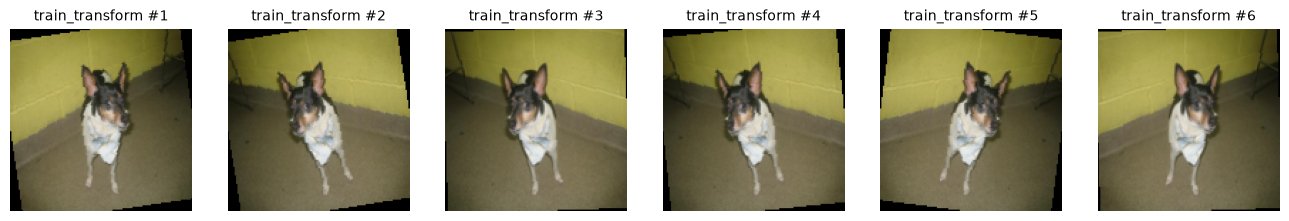

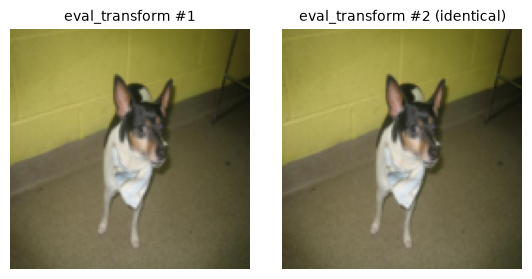

In [16]:
random.seed(SEED)
torch.manual_seed(SEED)

sample = Image.open(train_dog_paths[0]).convert("RGB")

augmented = []
for i in range(6):
    augmented.append(to_displayable(train_transform(sample)))

show_images(augmented, [f"train_transform #{i + 1}" for i in range(6)], columns=6, size=2.2)

# The evaluation pipeline gives the same result every time
show_images([to_displayable(eval_transform(sample)), to_displayable(eval_transform(sample))],
            ["eval_transform #1", "eval_transform #2 (identical)"],
            columns=2, size=2.8)


## 5. Why Resize?

A batch of images is a single block of numbers with one shape: `[batch, channels, height, width]`. There is no such thing as a batch where image 1 is 500x375 and image 4 is 200x300. So every image has to be brought to the same size before it can be stacked with the others.

Which size? A trade-off:[cite: 23]
* **Bigger** — more detail kept, but slower training and more memory.
* **Smaller** — faster, but fine detail (a whisker, an eye) disappears.

`128 x 128` is a good compromise for a teaching notebook: still recognisable to a human, small enough to train quickly.

One thing resizing does not change: the label. A squashed dog is still a dog. The Resize step touches the pixels; it never touches the answer.


original: (500, 471) (width, height)
resized : (128, 128)


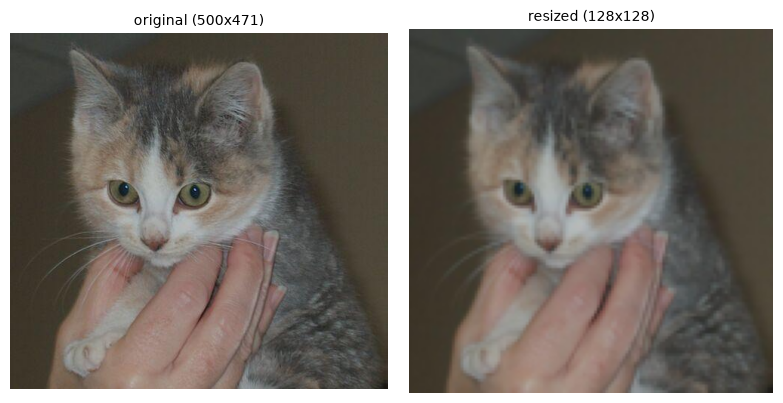

In [17]:
original = Image.open(train_cat_paths[0]).convert("RGB")
resized = transforms.Resize((IMG_SIZE, IMG_SIZE))(original)

print("original:", original.size, "(width, height)")
print("resized :", resized.size)

show_images([original, resized],
            [f"original ({original.size[0]}x{original.size[1]})", f"resized ({IMG_SIZE}x{IMG_SIZE})"],
            columns=2, size=4)

## 6. From image to tensor

A colour image is a grid of pixels, and each pixel has three numbers: red, green and blue. So an image is really a 3D grid of numbers. PyTorch wants that block arranged in a particular order. Let us watch the conversion happen.

In [18]:

image = Image.open(train_cat_paths[1]).convert("RGB")
resized = transforms.Resize((IMG_SIZE, IMG_SIZE))(image)

# Step 1 - as plain NumPy array
as_numpy = np.array(resized)
print("NumPy array")
print("  shape :", as_numpy.shape, " (height, width, channels) <- channel LAST")
print("  dtype :", as_numpy.dtype)
print("  values:", as_numpy.min(), "to", as_numpy.max())

# Step 2 - ToTensor
tensor = transforms.ToTensor()(resized)
print()
print("After ToTensor()")
print("  shape :", tuple(tensor.shape), " (channels, height, width) <- channel FIRST")
print("  dtype :", tensor.dtype)
print("  values:", round(tensor.min().item(), 3), "to", round(tensor.max().item(), 3))

# Step 3 - Normalize
normalized = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))(tensor)
print()
print("After Normalize(0.5, 0.5)")
print("  shape :", tuple(normalized.shape))
print("  values:", round(normalized.min().item(), 3), "to", round(normalized.max().item(), 3))


NumPy array
  shape : (128, 128, 3)  (height, width, channels) <- channel LAST
  dtype : uint8
  values: 1 to 254

After ToTensor()
  shape : (3, 128, 128)  (channels, height, width) <- channel FIRST
  dtype : torch.float32
  values: 0.004 to 0.996

After Normalize(0.5, 0.5)
  shape : (3, 128, 128)
  values: -0.992 to 0.992


## The three channels are three grayscale images

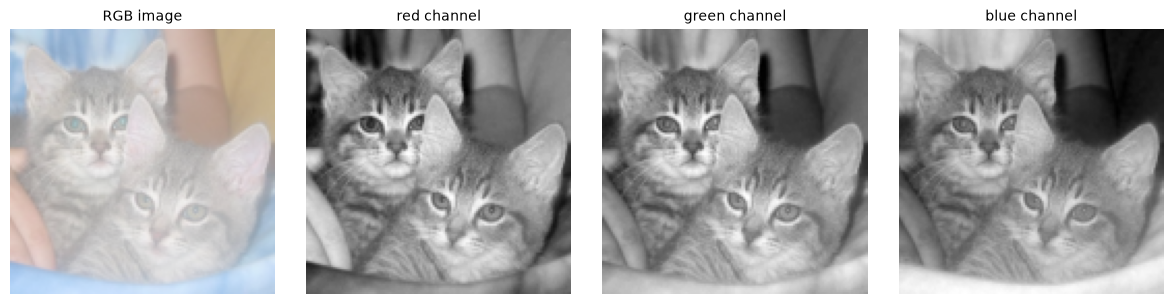

The whole tensor : (3, 128, 128)
One channel of it : (128, 128) <- just a 2D grid of numbers


In [19]:

red = tensor[0].numpy()
green = tensor[1].numpy()
blue = tensor[2].numpy()

show_images([to_displayable(tensor), red, green, blue],
            ["RGB image", "red channel", "green channel", "blue channel"],
            columns=4, size=3)

print("The whole tensor :", tuple(tensor.shape))
print("One channel of it :", tuple(tensor[0].shape), "<- just a 2D grid of numbers")


## 6.1 Datasets and DataLoaders

`ImageFolder` turns our folder structure into a labelled dataset. It looks inside `dataset/train/`, sorts the folder names alphabetically, and gives each one a number:
* `cats/` -> `0`
* `dogs/` -> `1`

That ordering is not just cosmetic. It fixes the meaning of the model's output for the whole notebook: the single number the network produces is evidence for class 1, which is dog. A high value means dog, a low value means cat.

The `DataLoader` then hands us the images in batches.

* `shuffle=True` for training only. Batches should not be all cats and then all dogs.
* `batch_size=32` — how many images the network looks at before each update.
* `num_workers` — how many extra processes load images in the background. On Windows and inside notebooks, `0` is the safe choice.

In [20]:
BATCH_SIZE = 32

train_dataset = ImageFolder(DATA_ROOT / "train", transform=train_transform)
val_dataset = ImageFolder(DATA_ROOT / "val", transform=eval_transform)
test_dataset = ImageFolder(DATA_ROOT / "test", transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

CLASS_NAMES = train_dataset.classes  # ['cats', 'dogs']

print("class to number :", train_dataset.class_to_idx)
print("train images    :", len(train_dataset), "->", len(train_loader), "batches")
print("val images      :", len(val_dataset), "->", len(val_loader), "batches")
print("test images     :", len(test_dataset), "->", len(test_loader), "batches")


class to number : {'cats': 0, 'dogs': 1}
train images    : 2000 -> 63 batches
val images      : 400 -> 13 batches
test images     : 400 -> 13 batches


In [21]:
batch_images, batch_labels = next(iter(train_loader))

print("images :", tuple(batch_images.shape))
print("labels :", tuple(batch_labels.shape))
print()
print("first 16 labels :", batch_labels[:16].tolist())
print("cats in this batch :", (batch_labels == 0).sum().item())
print("dogs in this batch :", (batch_labels == 1).sum().item())


images : (32, 3, 128, 128)
labels : (32,)

first 16 labels : [0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0]
cats in this batch : 18
dogs in this batch : 14


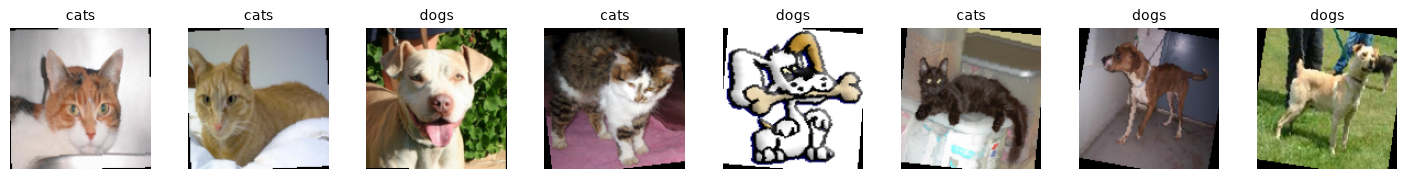

In [22]:
# Look at the batch the network will actually see: resized, normalised, classes mixed
first_eight = [to_displayable(batch_images[i]) for i in range(8)]
labels_eight = [CLASS_NAMES[batch_labels[i]] for i in range(8)]

show_images(first_eight, labels_eight, columns=8, size=1.8)

## 7. Build the CNN


Here is the whole architecture in one picture:

<pre>
Input       3 x 128 x 128
  ↓ Conv2d(3, 16, k=3, p=1) → ReLU → MaxPool(2)
Block 1     16 x  64 x  64
  ↓ Conv2d(16, 32, k=3, p=1) → ReLU → MaxPool(2)
Block 2     32 x  32 x  32
  ↓ Conv2d(32, 64, k=3, p=1) → ReLU → MaxPool(2)
Block 3     64 x  16 x  16
  ↓ Flatten
Vector      16384
  ↓ Linear → ReLU → Dropout → Linear
Output      1 number
</pre> 

Three blocks, all built the same way: convolution → activation → downsampling. That repeating pattern is the basic building block of almost every CNN; in the three blocks, a small ordinary neural network turns the result into one number.

Two choices worth naming now:

* `padding=1` with `kernel_size=3` keeps the height and width unchanged through the convolution. All the shrinking happens at a time. That makes the arithmetic easy to follow, which is exactly why we do it this way.
* Channels go up (`3` → `16` → `32` → `64`) while height and width go down (`128` → `64` → `32` → `16`). 

The model is written in two parts: `self.features` is the part that looks at the image; `self.classifier` is the part that makes the decision. Splitting them up is not required — it just makes the model easier to think about, and lets us peek inside later.

In [23]:
class SimpleCNN(nn.Module):
    """A small CNN for cat vs dog. Three convolution blocks, then a classifier."""

    def __init__(self):
        super().__init__()

        # The part that looks at the image
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # The part that makes the decision.
        # 64 * 16 * 16 = 16384 is the number of values coming out of the blocks above.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),            # ONE output: the score for "dog"
        )

    def forward(self, x):
        x = self.features(x)         # 3 x 128 x 128 -> 64 x 16 x 16
        x = self.classifier(x)       # 64 x 16 x 16 -> 1 number
        return x

torch.manual_seed(SEED)
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 8. Understand the CNN Architecture

Now slow down and read one line properly:

`nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)`

| Argument | Value | Meaning |
| :--- | :--- | :--- |
| `in_channels` | 3 | how many channels the input has — here red, green, blue |
| `out_channels` | 16 | how many filters this layer has, and therefore how many result images it produces |
| `kernel_size` | 3 | each filter is a 3x3 window |
| `stride` | 1 | the window moves one pixel at a time |
| `padding` | 1 | one ring of zeros around the border, so the output keeps the same height and width |

## The thing everybody mixes up at first

`in_channels` is not the number of filters.

`Conv2d(3, 16, 3)` means:
* the input has 3 channels,
* the layer has 16 filters,
* each filter is 3 * 3 * 3 — a 3x3 window looking at all 3 input channels at once, not a flat square,
* the output has 16 channels, one result image per filter.

So one filter holds 3 * 3 * 3 = 27 numbers, plus 1 bias = 28. The layer has 16 * 28 = 448 numbers to learn. Let us check that against PyTorch instead of trusting the arithmetic

In [24]:
first_conv = model.features[0]

print("layer               :", first_conv)
print("weight shape        :", tuple(first_conv.weight.shape))
print("                      (number of filters, input channels, height, width)")
print("bias shape          :", tuple(first_conv.bias.shape))
print()
print("one filter          :", tuple(first_conv.weight[0].shape), "<- 3x3 across all 3 input channels")
print("numbers to learn in this layer :", first_conv.weight.numel() + first_conv.bias.numel())

layer               : Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
weight shape        : (16, 3, 3, 3)
                      (number of filters, input channels, height, width)
bias shape          : (16,)

one filter          : (3, 3, 3) <- 3x3 across all 3 input channels
numbers to learn in this layer : 448


## 9. Track Tensor Shapes

In [25]:
# Take one image from our batch and push it through the layers one at a time
x = batch_images[:1].to(device)    # keep it as a batch of 1

model.eval()
print("Input           ", tuple(x.shape))

with torch.no_grad():
    for layer in model.features:
        x = layer(x)
        print(f"{layer.__class__.__name__:<15}", tuple(x.shape))

flattened = x.flatten(1)
print(f"{'Flatten':<15}", tuple(flattened.shape))

output = model(batch_images[:1].to(device))
print(f"{'Classifier':<15}", tuple(output.shape))

Input            (1, 3, 128, 128)
Conv2d          (1, 16, 128, 128)
ReLU            (1, 16, 128, 128)
MaxPool2d       (1, 16, 64, 64)
Conv2d          (1, 32, 64, 64)
ReLU            (1, 32, 64, 64)
MaxPool2d       (1, 32, 32, 32)
Conv2d          (1, 64, 32, 32)
ReLU            (1, 64, 32, 32)
MaxPool2d       (1, 64, 16, 16)
Flatten         (1, 16384)
Classifier      (1, 1)


## What just happened to the image

* The first number in every shape is the batch size (1 here). Every layer works on a whole batch at once.
* ReLU never changes the shape. It just replaces every negative value with 0 and leaves positives alone. Same shape in, same shape out. (If you got this wrong, you are in good company.)
* Convolution changes the number of channels. MaxPool changes the height and width. They are cleanly separated here because we used `padding=1`.
* The image started as $3 \times 128 \times 128 = 49,152$ numbers and arrives at the classifier as $64 \times 16 \times 16 = 16,384$. We traded "exactly which pixel is bright" for "which patterns are present, roughly where" — and for deciding cat vs dog, the second is more useful.


## 10. Feature Maps

A filter and a feature map are different things. The difference is the central idea of this notebook:

| | what it is | shape here | how many |
| :--- | :--- | :--- | :--- |
| **Filter (kernel)** | the learned numbers — the thing that looks | 3 x 3 x 3 | 16 in block 1 |
| **Feature map** | the result of sliding one filter over the image — what it saw | 128 x 128 | 16, one per filter |

Each filter slides over the input and computes a multiply-and-add at every position. The grid of results is that filter's feature map: bright where the filter pattern was found, dark where it was not.

Right now our model is **untrained**, so its filters are still random numbers and the feature maps will not look like much. Look at them anyway — this is the "before" picture, and we will run the same code again after training.

Two small helpers: one to get the feature maps out of a chosen layer, one to draw them.


In [26]:
def get_feature_maps(model, image, layer_index):
    """Push one image through model.features up to `layer_index` and return the result."""
    x = image.unsqueeze(0).to(device)    # add the batch dimension: C,H,W -> 1,C,H,W
    
    model.eval()
    with torch.no_grad():
        for layer in model.features[:layer_index + 1]:
            x = layer(x)
            
    return x[0].cpu()                    # remove the batch dimension again

def show_feature_maps(maps, title, how_many=16):
    """Draw the first `how_many` feature maps as a grid of small images."""
    how_many = min(how_many, len(maps))
    print(title, "- shape of this layer's output:", tuple(maps.shape))
    
    plt.figure(figsize=(12, 1.6 * np.ceil(how_many / 8)))
    for i in range(how_many):
        plt.subplot(int(np.ceil(how_many / 8)), 8, i + 1)
        plt.imshow(maps[i], cmap="viridis")
        plt.title(f"map {i}", fontsize=7)
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()


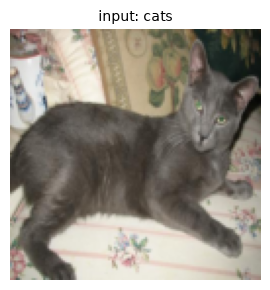

UNTRAINED: after the first Conv2d - shape of this layer's output: (16, 128, 128)


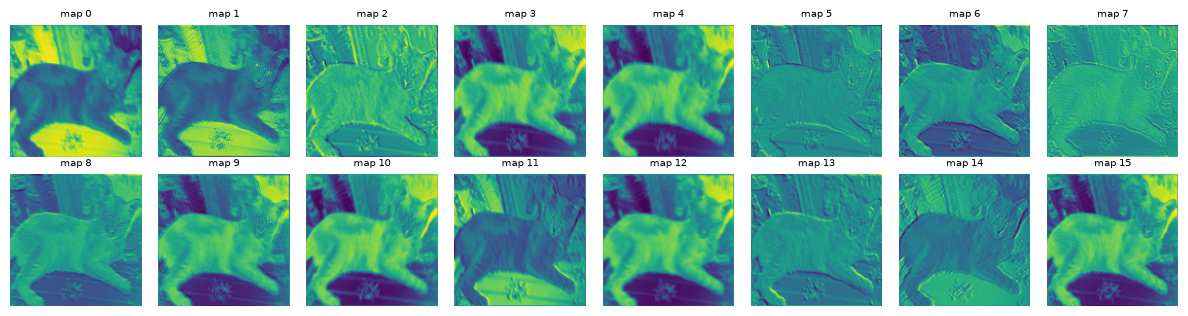

In [27]:
# One image that we will keep coming back to
demo_image, demo_label = test_dataset[3]
show_images([to_displayable(demo_image)], [f"input: {CLASS_NAMES[demo_label]}"], columns=1, size=3)

# Layer 0 is the first Conv2d
maps = get_feature_maps(model, demo_image, layer_index=0)
show_feature_maps(maps, "UNTRAINED: after the first Conv2d")


The layers of `model.features` are numbered in the order you wrote them:

| Index | Layer | Index | Layer | Index | Layer |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **0** | `Conv2d(3, 16)` | **3** | `Conv2d(16, 32)` | **6** | `Conv2d(32, 64)` |
| **1** | `ReLU` | **4** | `ReLU` | **7** | `ReLU` |
| **2** | `MaxPool2d` | **5** | `MaxPool2d` | **8** | `MaxPool2d` |

UNTRAINED: after the first ReLU - shape of this layer's output: (16, 128, 128)


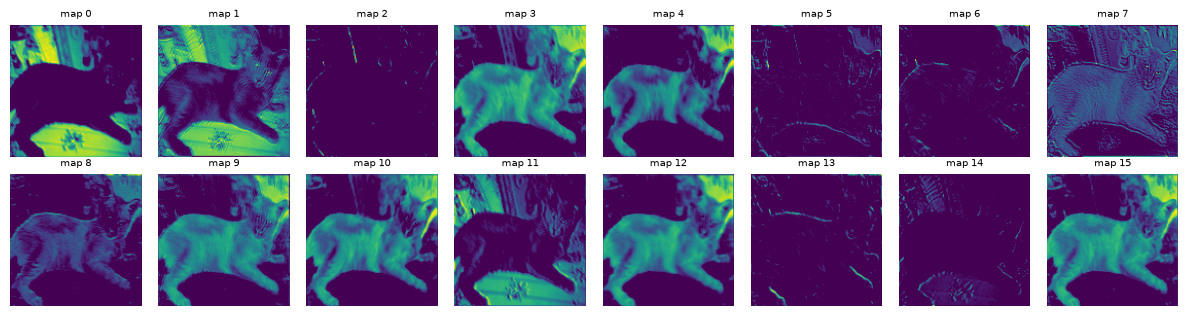

In [28]:
# Your experiments here
maps = get_feature_maps(model, demo_image, layer_index=1)
show_feature_maps(maps, "UNTRAINED: after the first ReLU")



## 11. Build the Classifier

The blocks end with 64 x 16 x 16: 64 feature maps, each a 16x16 grid. That is a description of the image, not a decision yet. We need a classifier to turn the description into a choice.

```text
64 x 16 x 16 feature maps
  ↓ Flatten                   lay the brick out as one long list
16384 numbers
  ↓ Linear(16384, 128) → ReLU → Dropout
128 numbers                   a short summary of the image
  ↓ Linear(128, 1)
1 number ("logit")            the score for "dog"
  ↓ sigmoid                   (only when we want to read it)
a probability between 0 and 1

```

Why one output and not two? With two classes, one number is enough: if the probability of dog is 0.9, then the probability of cat is 0.1. A second output would be redundant.

Why no sigmoid inside the model? Because the loss function in the next section applies it internally, in a more numerically stable way. The model gives score; we apply sigmoid ourselves only when we want a readable probability.

* score 0 → probability 0.5 — completely unsure
* score above 0 → probability above 0.5 — dog
* score below 0 → probability below 0.5 — cat

Dropout(0.3) randomly switches off 30% of those 128 numbers during training, so the model cannot lean too hard on any single feature. During testing we turn dropout off by calling model.eval().

In [29]:
model.eval()
with torch.no_grad():
    scores = model(batch_images[:6].to(device))       # shape [6, 1]
    probabilities = torch.sigmoid(scores)

print("true        score   P(dog)   prediction")
print("-" * 42)
for i in range(6):
    score = scores[i].item()
    probability = probabilities[i].item()
    prediction = CLASS_NAMES[1] if probability > 0.5 else CLASS_NAMES[0]
    print(f"{CLASS_NAMES[batch_labels[i]]:<10}{score:>6.2f}{probability:>10.2f}    {prediction}")

print()
print("The model is untrained, so these answers mean nothing -")
print("but the plumbing works: image in, one probability out.")

true        score   P(dog)   prediction
------------------------------------------
cats        0.02      0.51    dogs
cats        0.03      0.51    dogs
dogs        0.03      0.51    dogs
cats        0.05      0.51    dogs
dogs        0.03      0.51    dogs
cats        0.01      0.50    dogs

The model is untrained, so these answers mean nothing -
but the plumbing works: image in, one probability out.


## 12. Loss Function



We use `nn.BCEWithLogitsLoss` — binary cross entropy, applied to the raw score.

What it does, in one sentence: It measures how far the predicted probability is from the true answer (0 for cat, 1 for dog) and punishes big mistakes much harder than hesitant ones.

Two practical consequences for our code:

* The model must output a raw score, without a sigmoid. (Ours does.)


* The targets must be floats with the same shape as the output, not the whole numbers the DataLoader gives us. That is why you will see `labels.float().unsqueeze(1)` in the training loop: it turns a list of 32 labels into a column of 32 floats.


The numbers below show the shape of the punishment. Look at the last row.


In [30]:
criterion = nn.BCEWithLogitsLoss()

examples = [
    ("confident and RIGHT", 4.0),
    ("hesitant and right", 0.5),
    ("no idea", 0.0),
    ("hesitant and wrong", -0.5),
    ("confident and WRONG", -4.0),
]

print("The true answer is 'dog' (target = 1) in every row.")
print()
print("case                  score   P(dog)   loss")
print("-" * 46)

for description, score in examples:
    score_tensor = torch.tensor([[score]])
    target_tensor = torch.tensor([[1.0]])
    
    probability = torch.sigmoid(score_tensor).item()
    loss = criterion(score_tensor, target_tensor).item()
    
    print(f"{description:<22}{score:>8.1f}{probability:>9.2f}{loss:>8.3f}")


The true answer is 'dog' (target = 1) in every row.

case                  score   P(dog)   loss
----------------------------------------------
confident and RIGHT        4.0     0.98   0.018
hesitant and right         0.5     0.62   0.474
no idea                    0.0     0.50   0.693
hesitant and wrong        -0.5     0.38   0.974
confident and WRONG       -4.0     0.02   4.018


## 13. Optimizer

`optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)`

`model.parameters()` is every number the model can learn: the biases, the weights of the Linear layers, and the filters. This is worth pausing on — the optimizer adjusting "weights" is the mechanism by which the filters are discovered. It is how the model learns to see. We will look closer at what those weights become after training in Section 22.

`1e-3` (0.001) is the usual starting point for Adam. Too high and the loss bounces around; too low and training takes forever.

In [31]:
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

n_numbers = sum(p.numel() for p in model.parameters())
print(f"The optimizer will be adjusting", f"{n_numbers,}", "numbers.")
print("The first group of them is the filter bank of block 1:",
      tuple(model.features[0].weight.shape))

The optimizer will be adjusting (2120993,) numbers.
The first group of them is the filter bank of block 1: (16, 3, 3, 3)


## 14. Training Loop

No framework, no `.fit()`: One function, ten steps, all visible. Read it once before running it.

1. `model.train()` — put the model in training mode
2. `for images, labels in loader:` — feed data in batches
3. `images = images.to(device)` — to where the model is
4. `outputs = model(images)` — forward pass
5. `loss = criterion(outputs, labels)` — how wrong was it?
6. `optimizer.zero_grad()` — clear the gradients from last time
7. `loss.backward()` — BACKWARD pass — work out the gradients
8. `optimizer.step()` — update every number in the model
9. `total_loss += ...` — keep track of the loss
10. `correct += ...` — keep track of the accuracy

Two things that catch people out:
* `optimizer.zero_grad()` is not optional. PyTorch adds up gradients by default. Forget this line and batch 5's update is based on batches 1 to 5 added together.
* `loss.item()` takes the plain number out of the tensor. Adding up the tensors themselves would slowly eat your memory.

In [32]:
def train_one_epoch(model, loader, criterion, optimizer):
    """Go through the training set once, learning as we go. Returns loss and accuracy."""
    model.train()                                           # 1. training mode (dropout is ON)
    
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in loader:                           # 2. one batch at a time
        images = images.to(device)                          # 3. move to the device
        targets = labels.float().unsqueeze(1).to(device)
        
        outputs = model(images)                             # 4. forward pass
        loss = criterion(outputs, targets)                  # 5. how wrong?

        optimizer.zero_grad()                               # 6. clear old gradients
        loss.backward()                                     # 7. backpropagation
        optimizer.step()                                    # 8. update the model

        total_loss += loss.item()                           # 9. track the loss

        predictions = (torch.sigmoid(outputs) > 0.5).float() # 10. track accuracy
        correct += (predictions == targets).sum().item()
        total += len(labels)
        
    return total_loss / len(loader), correct / total


## 15. Validation Loop

Almost the same loop, with three deliberate differences:

* `model.eval()` puts the model in evaluation mode. For us that means dropout is switched off.
* `torch.no_grad()` tells PyTorch not to track gradients for learning. We are not going to call `backward()` here, so this saves time and memory.
* `No loss.backward()`, no `optimizer.step()`. Nothing is updated.

Why must validation not update the model? Because the validation set's job is to give an honest estimate of how the model does on images it has never seen from. The moment a validation image changes a weight, it is no longer unseen, and the number it produces stops meaning anything.

We look at the validation score after every epoch, to see how training is going. The test set is stricter: we look at it once, at the very end, in Section 17.

In [33]:
def evaluate(model, loader, criterion):
    """Go through a dataset without learning. Returns loss and accuracy."""
    model.eval()                                      # evaluation mode (dropout is OFF)
    
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():                             # no learning happens in here
        for images, labels in loader:
            images = images.to(device)
            targets = labels.float().unsqueeze(1).to(device)
            
            outputs = model(images)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item()
            
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            correct += (predictions == targets).sum().item()
            total += len(labels)
            
    return total_loss / len(loader), correct / total


## 15.1 Run the training

Now put the two loops together. Each epoch: train on all 2,000 training images, then check on the 400 validation images.

Expect a few minutes on a CPU, well under a minute on a GPU. If it is too slow, lower `EPOCHS`.

In [34]:
import time

EPOCHS = 5
SEED = 42

# Start from a fresh model, so this cell gives the same result every time you run it
torch.manual_seed(SEED)
model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print(f"epoch  train_loss  train_acc  val_loss  val_acc    time")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    started = time.time()
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    print(f"{epoch:5}  {train_loss:11.3f}  {train_acc:10.3f}  {val_loss:9.3f}  {val_acc:9.3f}  {time.time() - started:6.1f}s")

print("-" * 60)
print(f"best validation accuracy: {round(max(history['val_acc']), 3)}")

torch.save(model.state_dict(), "cnn_cat_dog.pt")
print("model saved to cnn_cat_dog.pt")


epoch  train_loss  train_acc  val_loss  val_acc    time
------------------------------------------------------------
    1        0.695       0.520      0.687      0.545    11.9s
    2        0.680       0.587      0.679      0.573    11.5s
    3        0.668       0.608      0.696      0.565    28.0s
    4        0.630       0.656      0.633      0.642    30.1s
    5        0.602       0.683      0.652      0.618    42.5s
------------------------------------------------------------
best validation accuracy: 0.642
model saved to cnn_cat_dog.pt


## 16. Plot the Training Curves

The table above is hard to read. The same four numbers drawn as curves are much easier, and reading these pl

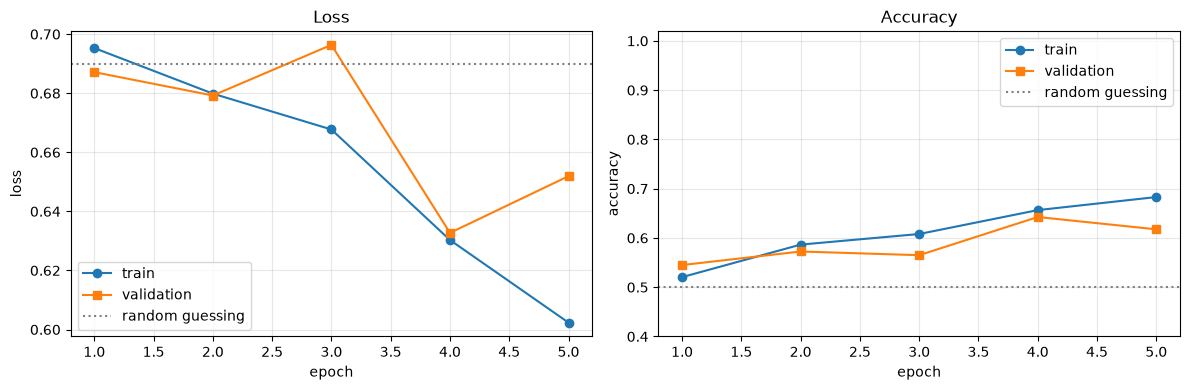

final train accuracy: 0.683
final val accuracy  : 0.618
gap between them    : 0.066


In [35]:
epoch_numbers = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epoch_numbers, history["train_loss"], "o-", label="train")
plt.plot(epoch_numbers, history["val_loss"], "s-", label="validation")
plt.axhline(0.69, color="gray", linestyle=":", label="random guessing")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epoch_numbers, history["train_acc"], "o-", label="train")
plt.plot(epoch_numbers, history["val_acc"], "s-", label="validation")
plt.axhline(0.5, color="gray", linestyle=":", label="random guessing")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.ylim(0.4, 1.02)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

gap = history["train_acc"][-1] - history["val_acc"][-1]
print(f"final train accuracy: {round(history['train_acc'][-1], 3)}")
print(f"final val accuracy  : {round(history['val_acc'][-1], 3)}")
print(f"gap between them    : {round(gap, 3)}")

## 16.1 Feature maps, now that the filters are trained


TRAINED: after the first Conv2d - shape of this layer's output: (16, 128, 128)


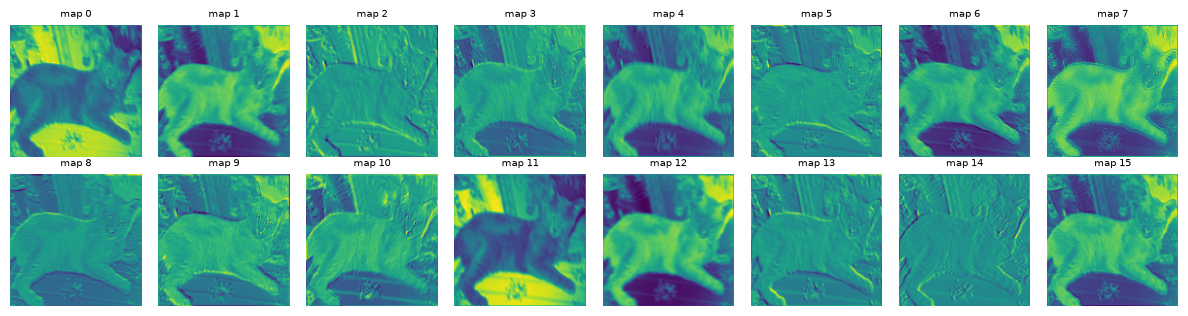

TRAINED: after the third Conv2d (first 16 of 64 maps) - shape of this layer's output: (64, 32, 32)


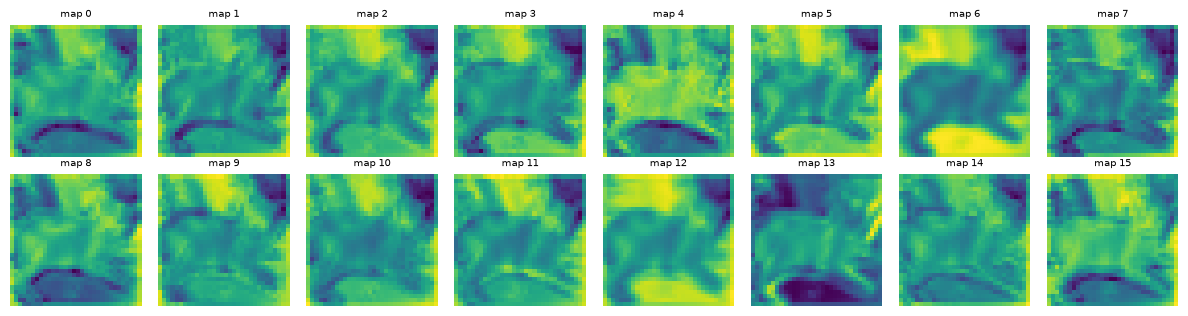

In [36]:
maps = get_feature_maps(model, demo_image, layer_index=0)
show_feature_maps(maps, "TRAINED: after the first Conv2d")

maps = get_feature_maps(model, demo_image, layer_index=6)
show_feature_maps(maps, "TRAINED: after the third Conv2d (first 16 of 64 maps)")


## 17. Evaluate on the Test Set

The test set has been untouched until now. No gradient came from it, and no decision about epochs or architecture was based on it. It gives an honest number: an estimate of how the model does on genuinely new photos.


In [37]:
test_loss, test_acc = evaluate(model, test_loader, criterion)

n_test = len(test_dataset)
n_correct = round(test_acc * n_test)

print(f"test loss     : {round(test_loss, 3)}")
print(f"test accuracy : {round(test_acc, 3)}")
print(f"correct       : {n_correct} out of {n_test}")
print(f"incorrect     : {n_test - n_correct} out of {n_test}")
print()
print(f"for comparison: random guessing = 0.5")

test loss     : 0.624
test accuracy : 0.647
correct       : 259 out of 400
incorrect     : 141 out of 400

for comparison: random guessing = 0.5


## 17.1 Collect the predictions

Everything below needs the model's answer for each individual test image, so we collect them all once. Because `test_loader` was built with shuffle=False, the answers come back in the same order as the dataset: answer number `i` belongs to `test_dataset[i]`.

collected 400 predictions
accuracy from these arrays: 0.648


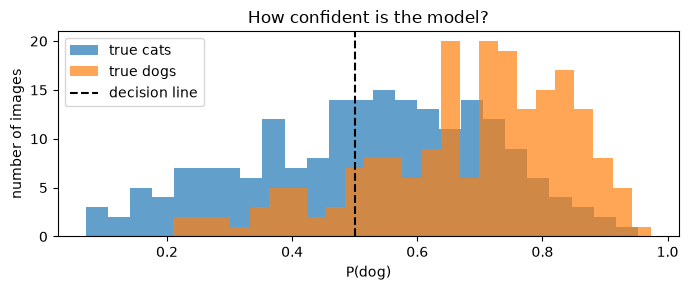

In [38]:
model.eval()

all_probabilities = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        probabilities = torch.sigmoid(outputs)
        
        all_probabilities.extend(probabilities.cpu().flatten().tolist())
        all_labels.extend(labels.tolist())

probs = np.array(all_probabilities)       # P(dog) for each test image
y_true = np.array(all_labels)             # 0 = cat, 1 = dog
preds = (probs > 0.5).astype(int)         # what the model decided

print(f"collected {len(probs)} predictions")
print(f"accuracy from these arrays: {round((preds == y_true).mean(), 3)}")

plt.figure(figsize=(7, 3))
plt.hist(probs[y_true == 0], bins=25, alpha=0.7, label="true cats")
plt.hist(probs[y_true == 1], bins=25, alpha=0.7, label="true dogs")
plt.axvline(0.5, color="black", linestyle="--", label="decision line")
plt.xlabel("P(dog)")
plt.ylabel("number of images")
plt.title("How confident is the model?")
plt.legend()
plt.tight_layout()
plt.show()

## 18. Confusion Matrix

| | predicted cat | predicted dog |
| --- | --- | --- |
| actually cat | True Negative (TN) — correct | False Positive (FP) — a cat called a dog |
| actually dog | False Negative (FN) — a dog called a cat | True Positive (TP) — correct |

The diagonal is what the model got right. Everything off the diagonal is a mistake, and the two kinds of mistake are not always equally bad depending on the setting, one of them can be far more expensive than the other.

We count them with a simple loop, because writing it once makes the definitions stick.

True Negative (cat -> cat) : 85
False Positive (cat -> dog) : 115
False Negative (dog -> cat) : 26
True Positive (dog -> dog) : 174

accuracy on cats : 0.425
accuracy on dogs : 0.87


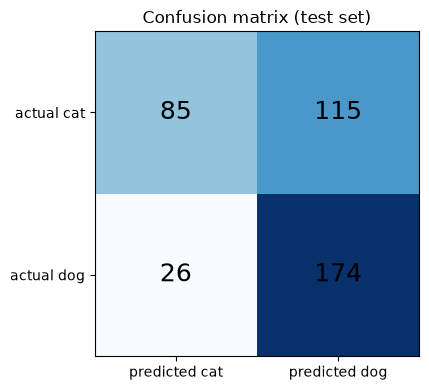

In [39]:
true_negative = 0  # cat, called cat
false_positive = 0  # cat, called dog
false_negative = 0  # dog, called cat
true_positive = 0  # dog, called dog

for true_label, predicted_label in zip(y_true, preds):
    if true_label == 0 and predicted_label == 0:
        true_negative += 1
    elif true_label == 0 and predicted_label == 1:
        false_positive += 1
    elif true_label == 1 and predicted_label == 0:
        false_negative += 1
    else:
        true_positive += 1

print("True Negative (cat -> cat) :", true_negative)
print("False Positive (cat -> dog) :", false_positive)
print("False Negative (dog -> cat) :", false_negative)
print("True Positive (dog -> dog) :", true_positive)
print()
print("accuracy on cats :", round(true_negative / (true_negative + false_positive), 3))
print("accuracy on dogs :", round(true_positive / (true_positive + false_negative), 3))

matrix = np.array([[true_negative, false_positive],
                   [false_negative, true_positive]])

plt.figure(figsize=(4.5, 4))
plt.imshow(matrix, cmap="Blues")
plt.xticks([0, 1], ["predicted cat", "predicted dog"])
plt.yticks([0, 1], ["actual cat", "actual dog"])
for row in range(2):
    for column in range(2):
        plt.text(column, row, matrix[row, column], ha="center", va="center", fontsize=18)
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()


## 19. Visualize Predictions

Numbers are abstract. Look at the actual images together with what the model said. Green means correct, red means wrong, and the subtitle gives P(dog)

In [40]:
def show_predictions(indices, title):
    """Show test images with the true label, the prediction and the probability."""
    plt.figure(figsize=(15, 3 * int(np.ceil(len(indices) / 6))))
    
    for position, index in enumerate(indices):
        image, true_label = test_dataset[index]
        probability = probs[index]
        predicted_label = preds[index]
        is_correct = (predicted_label == true_label)
        
        plt.subplot(int(np.ceil(len(indices) / 6)), 6, position + 1)
        plt.imshow(to_displayable(image))
        plt.title(f"actual: {CLASS_NAMES[true_label]}\n"
                  f"predicted: {CLASS_NAMES[predicted_label]}\n"
                  f"P(dog) = {probability:.2f}",
                  fontsize=9,
                  color="green" if is_correct else "red")
        plt.axis("off")
        
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


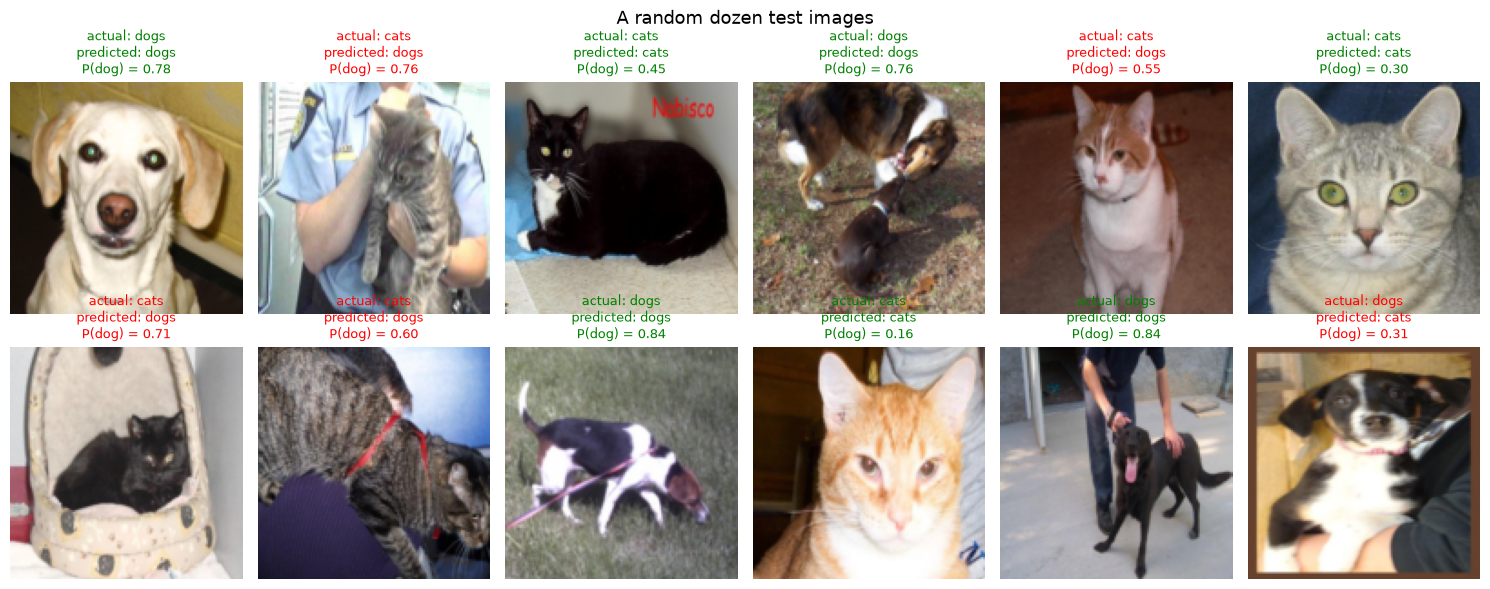

In [41]:


twelve_random = random.sample(range(len(test_dataset)), 12)
show_predictions(twelve_random, "A random dozen test images")


259 correct, 141 wrong


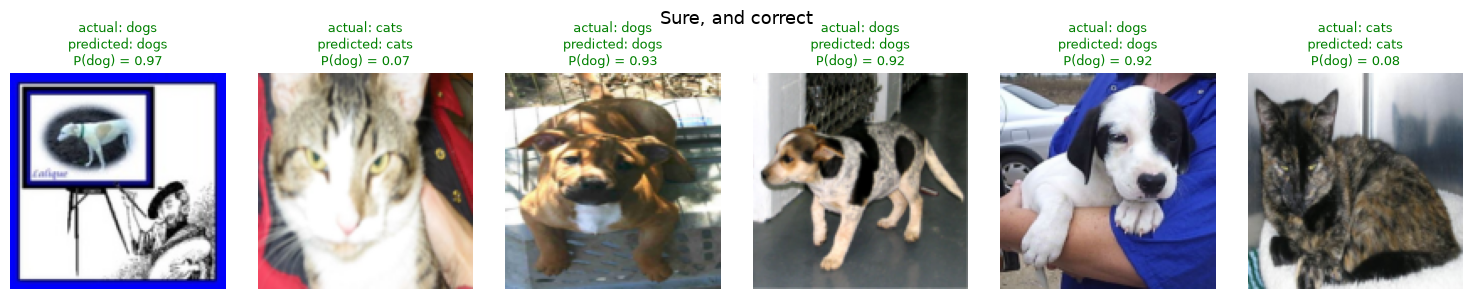

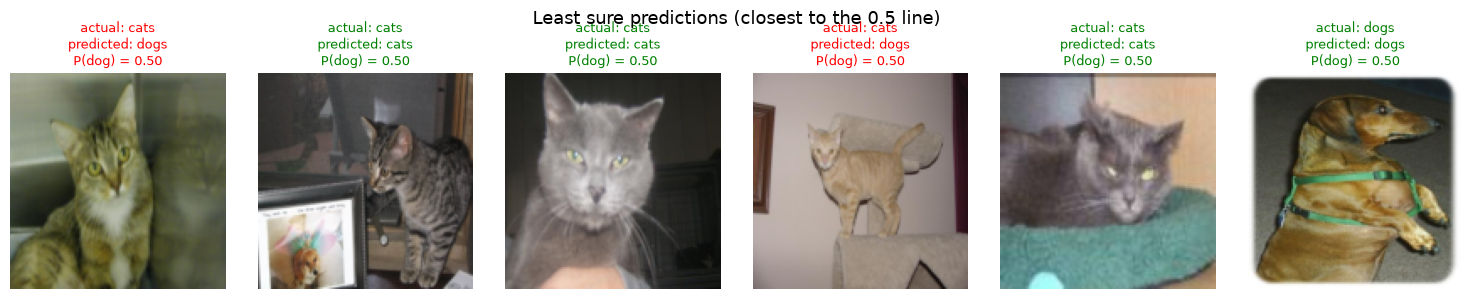

In [42]:
# Split the test images into the ones we got right and the ones we got wrong
correct_indices = [i for i in range(len(probs)) if preds[i] == y_true[i]]
wrong_indices = [i for i in range(len(probs)) if preds[i] != y_true[i]]

print(len(correct_indices), "correct,", len(wrong_indices), "wrong")

# How sure was the model about the answer it gave? (0.5 = unsure, 1.0 = completely sure)
confidence = np.maximum(probs, 1 - probs)

# The ones it was most sure about and right
most_sure_correct = sorted(correct_indices, key=lambda i: -confidence[i])[:6]
show_predictions(most_sure_correct, "Sure, and correct")

# The ones it hesitated over the most
least_sure = sorted(range(len(probs)), key=lambda i: confidence[i])[:6]
show_predictions(least_sure, "Least sure predictions (closest to the 0.5 line)")


## 20. Investigate Failure Cases

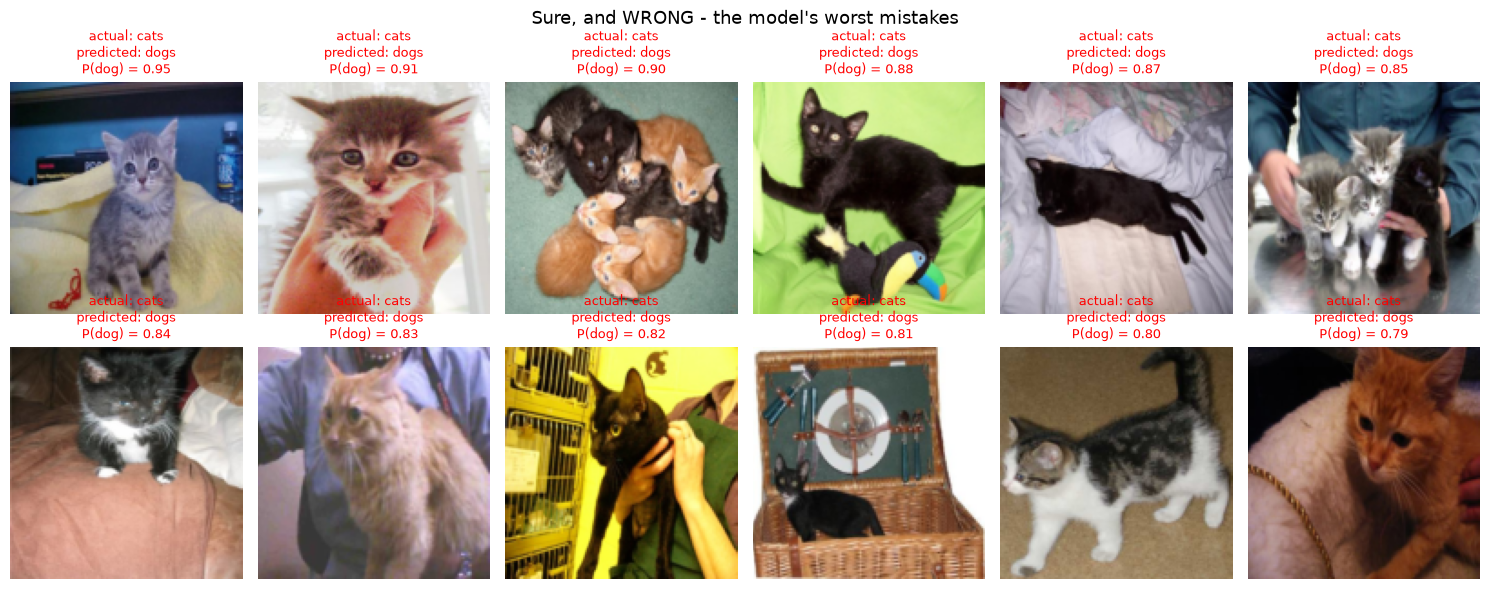

In [43]:
most_sure_wrong = sorted(wrong_indices, key=lambda i: -confidence[i])[:12]
show_predictions(most_sure_wrong, "Sure, and WRONG - the model's worst mistakes")